# Práctica 1: Análisis Exploratorio de datos

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn

## Conjunto de datos

El conjunto de datos con el que se trabaja es el siguiente: Censos Económicos (CE) 2024. Este conjunto de datos tiene a los resultados definitivos de los Censos Económicos 2024 de parte del INEGI, en particular, se trabajaron con los datos recabados del estado de Baja California. Estos datos describen las principales variables económicas de todos los establecimientos productores de bienes, comercializadores de mercancías y prestadores de servicios del país.

Estos datos se recuperaron de la siguiente liga:

[Censos Económicos (CE) 2024.](https://www.inegi.org.mx/programas/ce/2024/#datos_abiertos)

In [204]:
df_datos = pd.read_csv('./data/conjunto_de_datos/tr_ce_bc_2024.csv')
df_datos

,E03,E04,SECTOR,SUBSECTOR,RAMA,SUBRAMA,CLASE,ID_ESTRATO,CODIGO,UE,...,M090A,P100A,P100B,P030A,P030B,Q010A,Q020A,Q030A,Q400A,Q900A
0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TOTAL DE SECTOR,120980,...,6670.193,30747.310,31448.680,1742.615,1889.184,106845.762,122294.019,18328.352,16446.989,30478.013
1,2,NaN,NaN,NaN,NaN,NaN,NaN,1.0,TOTAL DE SECTOR,109657,...,763.086,6208.268,6160.430,88.781,134.507,9005.038,21410.611,4820.628,2367.218,6643.502
2,2,NaN,NaN,NaN,NaN,NaN,NaN,2.0,TOTAL DE SECTOR,8855,...,869.409,11966.040,12132.880,139.648,143.711,23201.803,18371.550,5152.936,4791.622,8713.162
3,2,NaN,NaN,NaN,NaN,NaN,NaN,3.0,TOTAL DE SECTOR,1895,...,1706.851,11068.434,11797.906,304.228,304.786,23193.557,16537.057,4789.186,3590.638,8273.810
4,2,NaN,NaN,NaN,NaN,NaN,NaN,4.0,TOTAL DE SECTOR,573,...,3330.847,1504.568,1357.464,1209.958,1306.180,51445.364,65974.801,3565.602,5697.511,6847.539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19711,2,7.0,81,813.0,8132.0,NaN,NaN,1.0,8132,5,...,0.000,0.000,0.000,0.000,0.000,0.050,0.760,0.080,0.002,0.005
19712,2,7.0,81,813.0,8132.0,81323.0,NaN,NaN,81323,5,...,0.000,0.000,0.000,0.000,0.000,0.050,0.760,0.080,0.002,0.005
19713,2,7.0,81,813.0,8132.0,81323.0,NaN,1.0,81323,5,...,0.000,0.000,0.000,0.000,0.000,0.050,0.760,0.080,0.002,0.005
19714,2,7.0,81,813.0,8132.0,81323.0,813230.0,NaN,813230,5,...,0.000,0.000,0.000,0.000,0.000,0.050,0.760,0.080,0.002,0.005


En el conjunto de datos se tiene una cantidad de 19,716 registros con 107 atributos. Se puede observar que muchos de esos atributos tienen una clave la cuál se tiene una descripción asociada en el archivo:

[Diccionario de datos](./data/diccionario_de_datos/diccionario_de_datos_ce2024.csv)


## Diccionario de datos

In [205]:
df_diccionario = pd.read_csv('./data/diccionario_de_datos/diccionario_de_datos_ce2024.csv')
df_diccionario

,COLUMNA,DESCRIPCION,TIPO_DATO,LONGITUD,CODIGO_VALIDO
0,E03,Clave de la entidad federativa,VARCHAR2,2,"Vacío, 01 a 32"
1,E04,Clave del municipio,VARCHAR2,3,"Vacío, 001 a 570"
2,SECTOR,Sector,VARCHAR2,5,"Vacío, 11 a 81"
3,SUBSECTOR,Subsector,VARCHAR2,3,"Vacío, 112 a 813"
4,RAMA,Rama,VARCHAR2,4,"Vacío, 1125 a 8132"
...,...,...,...,...,...
102,Q010A,Acervo total de maquinaria y equipo de producc...,NUMBER,"16,4",0-999999999999.9999
103,Q020A,Acervo total de bienes inmuebles (millones de ...,NUMBER,"16,4",0-999999999999.9999
104,Q030A,Acervo total de unidades y equipo de transport...,NUMBER,"16,4",0-999999999999.9999
105,Q400A,Acervo total de equipo de cómputo y periférico...,NUMBER,"16,4",0-999999999999.9999


Para este análisis únicamente nos enfocaremos en las siguientes variables:
 
E04 Clave del municipio


In [206]:
# df_subset.dtype
df_datos

,E03,E04,SECTOR,SUBSECTOR,RAMA,SUBRAMA,CLASE,ID_ESTRATO,CODIGO,UE,...,M090A,P100A,P100B,P030A,P030B,Q010A,Q020A,Q030A,Q400A,Q900A
0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TOTAL DE SECTOR,120980,...,6670.193,30747.310,31448.680,1742.615,1889.184,106845.762,122294.019,18328.352,16446.989,30478.013
1,2,NaN,NaN,NaN,NaN,NaN,NaN,1.0,TOTAL DE SECTOR,109657,...,763.086,6208.268,6160.430,88.781,134.507,9005.038,21410.611,4820.628,2367.218,6643.502
2,2,NaN,NaN,NaN,NaN,NaN,NaN,2.0,TOTAL DE SECTOR,8855,...,869.409,11966.040,12132.880,139.648,143.711,23201.803,18371.550,5152.936,4791.622,8713.162
3,2,NaN,NaN,NaN,NaN,NaN,NaN,3.0,TOTAL DE SECTOR,1895,...,1706.851,11068.434,11797.906,304.228,304.786,23193.557,16537.057,4789.186,3590.638,8273.810
4,2,NaN,NaN,NaN,NaN,NaN,NaN,4.0,TOTAL DE SECTOR,573,...,3330.847,1504.568,1357.464,1209.958,1306.180,51445.364,65974.801,3565.602,5697.511,6847.539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19711,2,7.0,81,813.0,8132.0,NaN,NaN,1.0,8132,5,...,0.000,0.000,0.000,0.000,0.000,0.050,0.760,0.080,0.002,0.005
19712,2,7.0,81,813.0,8132.0,81323.0,NaN,NaN,81323,5,...,0.000,0.000,0.000,0.000,0.000,0.050,0.760,0.080,0.002,0.005
19713,2,7.0,81,813.0,8132.0,81323.0,NaN,1.0,81323,5,...,0.000,0.000,0.000,0.000,0.000,0.050,0.760,0.080,0.002,0.005
19714,2,7.0,81,813.0,8132.0,81323.0,813230.0,NaN,813230,5,...,0.000,0.000,0.000,0.000,0.000,0.050,0.760,0.080,0.002,0.005


In [223]:
df_subset = df_datos[
    ['E04', 'SECTOR', 'A111A', 'H001A', 'A800A', ]
].copy()
print(df_subset.dtypes)
df_subset

E04         Int64
SECTOR     object
A111A     float64
H001A     float64
A800A     float64
dtype: object


,E04,SECTOR,A111A,H001A,A800A
0,<NA>,NaN,978451.037292,1155112.0,1360494.709
1,<NA>,NaN,138480.510127,295638.0,224075.288
2,<NA>,NaN,146490.520000,185215.0,291136.161
3,<NA>,NaN,194329.725000,198445.0,327854.041
4,<NA>,NaN,499150.282165,475814.0,517429.219
...,...,...,...,...,...
19711,7,81,0.524000,13.0,0.524
19712,7,81,0.524000,13.0,0.524
19713,7,81,0.524000,13.0,0.524
19714,7,81,0.524000,13.0,0.524


Se observa un problema con el tipo de datos del atributo sector, aparece como objeto. Al hacer una pequeña

<Axes: >

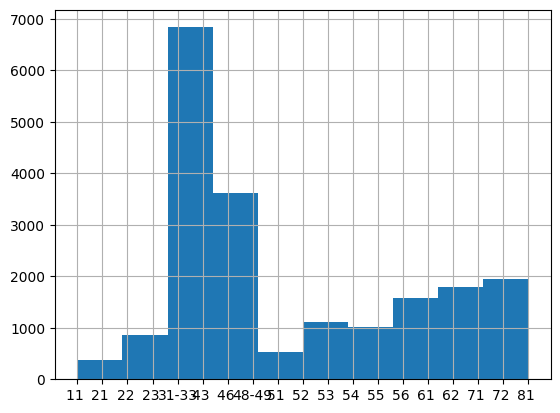

In [226]:
df_subset['E04'] = df_subset['E04'].astype('Int64')
df_subset['SECTOR'].hist()
# df_subset['E04'].hist()

In [209]:
df_datos.loc[
    df_datos['E03'] == 2,
    ['E04', 'A111A']
]

,E04,A111A
0,NaN,978451.037292
1,NaN,138480.510127
2,NaN,146490.520000
3,NaN,194329.725000
4,NaN,499150.282165
...,...,...
19711,7.0,0.524000
19712,7.0,0.524000
19713,7.0,0.524000
19714,7.0,0.524000


In [210]:
df_datos['E04'] = df_datos['E04'].astype('Int64')

In [211]:
df_datos

,E03,E04,SECTOR,SUBSECTOR,RAMA,SUBRAMA,CLASE,ID_ESTRATO,CODIGO,UE,...,M090A,P100A,P100B,P030A,P030B,Q010A,Q020A,Q030A,Q400A,Q900A
0,2,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,TOTAL DE SECTOR,120980,...,6670.193,30747.310,31448.680,1742.615,1889.184,106845.762,122294.019,18328.352,16446.989,30478.013
1,2,<NA>,NaN,NaN,NaN,NaN,NaN,1.0,TOTAL DE SECTOR,109657,...,763.086,6208.268,6160.430,88.781,134.507,9005.038,21410.611,4820.628,2367.218,6643.502
2,2,<NA>,NaN,NaN,NaN,NaN,NaN,2.0,TOTAL DE SECTOR,8855,...,869.409,11966.040,12132.880,139.648,143.711,23201.803,18371.550,5152.936,4791.622,8713.162
3,2,<NA>,NaN,NaN,NaN,NaN,NaN,3.0,TOTAL DE SECTOR,1895,...,1706.851,11068.434,11797.906,304.228,304.786,23193.557,16537.057,4789.186,3590.638,8273.810
4,2,<NA>,NaN,NaN,NaN,NaN,NaN,4.0,TOTAL DE SECTOR,573,...,3330.847,1504.568,1357.464,1209.958,1306.180,51445.364,65974.801,3565.602,5697.511,6847.539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19711,2,7,81,813.0,8132.0,NaN,NaN,1.0,8132,5,...,0.000,0.000,0.000,0.000,0.000,0.050,0.760,0.080,0.002,0.005
19712,2,7,81,813.0,8132.0,81323.0,NaN,NaN,81323,5,...,0.000,0.000,0.000,0.000,0.000,0.050,0.760,0.080,0.002,0.005
19713,2,7,81,813.0,8132.0,81323.0,NaN,1.0,81323,5,...,0.000,0.000,0.000,0.000,0.000,0.050,0.760,0.080,0.002,0.005
19714,2,7,81,813.0,8132.0,81323.0,813230.0,NaN,813230,5,...,0.000,0.000,0.000,0.000,0.000,0.050,0.760,0.080,0.002,0.005


In [212]:
df_entidad_municipio = pd.read_csv('./data/catalogos/tc_entidad_municipio.csv')

In [213]:
# print(df_entidad_municipio['E03'].dtype)

municipios = df_entidad_municipio.loc[
    df_entidad_municipio['E03'] == 2,
    ['E04', 'NOM_MUN']
]

municipios['NOM_MUN']

11              Ensenada
12              Mexicali
13                Tecate
14               Tijuana
15    Playas de Rosarito
16           San Quintín
17            San Felipe
Name: NOM_MUN, dtype: object

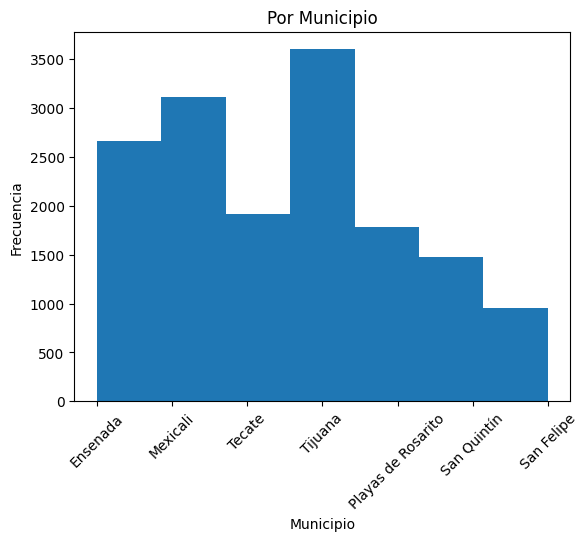

In [214]:
municipios = df_entidad_municipio.loc[
    df_entidad_municipio['E03'] == 2,
    ['E04', 'NOM_MUN']
]

plt.hist(df_datos['E04'].dropna(), bins=7)
plt.title('Por Municipio')
plt.xlabel('Municipio')
plt.ylabel('Frecuencia')

plt.xticks(
    municipios['E04'],
    municipios['NOM_MUN'],
    rotation=45
)

plt.show()

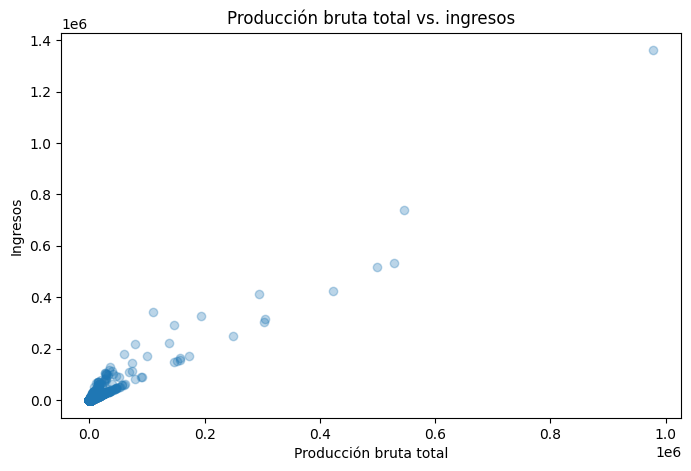

In [232]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_subset['A111A'],
    df_subset['A800A'],
    alpha=0.3
)

plt.xlabel('Producción bruta total')
plt.ylabel('Ingresos')
plt.title('Producción bruta total vs. ingresos')

plt.show()

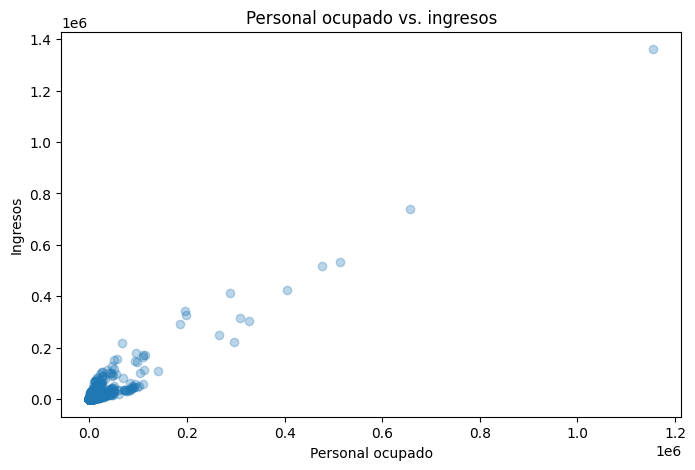

In [231]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_subset['H001A'],
    df_subset['A800A'],
    alpha=0.3
)

plt.xlabel('Personal ocupado')
plt.ylabel('Ingresos')
plt.title('Personal ocupado vs. ingresos')

plt.show()

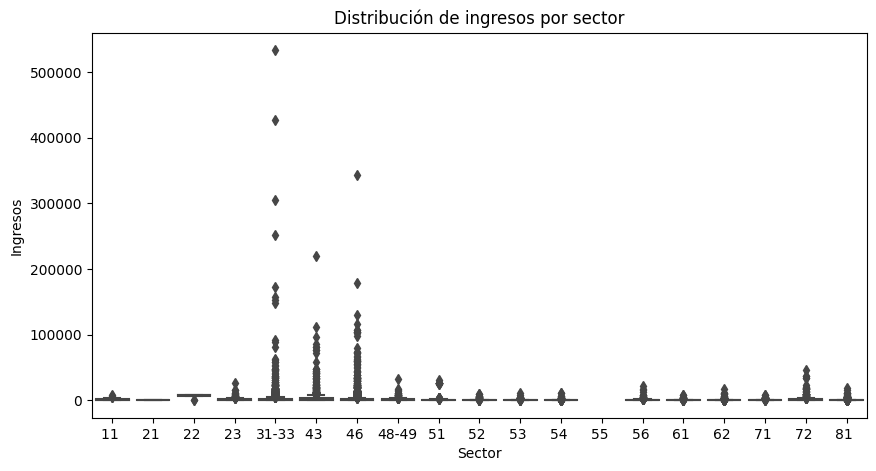

In [234]:
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_subset,
    x='SECTOR',
    y='A800A'
)

plt.xlabel('Sector')
plt.ylabel('Ingresos')
plt.title('Distribución de ingresos por sector')

plt.show()